# 📈 Mutual Fund Analytics Platform

# 06 - Monte Carlo Simulation for NAV Forecasting

### Bluestock Fintech Capstone Project

**Author:** Utsav Ratpiya

---

## 📌 Objective

Monte Carlo Simulation is a quantitative finance technique used to estimate the possible future performance of an investment under uncertainty.

In this notebook, historical NAV data is used to simulate thousands of possible future NAV paths over a **5-year investment horizon**.

The simulation helps estimate:

- Expected Future NAV
- Best Case Scenario
- Worst Case Scenario
- Investment Risk
- Probability Distribution of Future NAV
- Long-Term Growth Trend

---

## 🎯 Learning Outcomes

After completing this notebook, we will be able to:

- Calculate historical daily returns
- Estimate expected return and volatility
- Generate random future returns
- Simulate future NAV values
- Analyze investment uncertainty
- Visualize risk using Monte Carlo Simulation

---

## 📊 Project Workflow

```
Historical NAV
        │
        ▼
Daily Returns
        │
        ▼
Expected Return & Volatility
        │
        ▼
Monte Carlo Simulation
        │
        ▼
Future NAV Paths
        │
        ▼
Risk Analysis
        │
        ▼
Investment Insights
```

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

plt.style.use("ggplot")

print("=" * 70)
print("MONTE CARLO SIMULATION")
print("=" * 70)

MONTE CARLO SIMULATION


In [2]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed"

REPORT_PATH = PROJECT_ROOT / "reports"

CHART_PATH = REPORT_PATH / "charts"

CHART_PATH.mkdir(parents=True, exist_ok=True)

NAV_FILE = DATA_PATH / "02_nav_history_cleaned.csv"

print("Project Root :", PROJECT_ROOT.resolve())
print("NAV Dataset  :", NAV_FILE)
print("Charts Path  :", CHART_PATH)

Project Root : C:\Users\Utsav\OneDrive\Desktop\Bluestock internship\Capstone Mutual Fund Analytics
NAV Dataset  : ..\data\processed\02_nav_history_cleaned.csv
Charts Path  : ..\reports\charts


# 📂 Load Historical NAV Dataset

The cleaned NAV dataset contains the historical Net Asset Value (NAV) of mutual fund schemes.

This dataset will be used to estimate historical return and volatility, which are the key inputs for the Monte Carlo simulation.

### Dataset Validation

The following checks are performed:

- File availability
- Dataset dimensions
- Missing values
- Duplicate records
- Date range
- Number of mutual fund schemes

In [3]:
# ============================================================
# Load NAV Dataset
# ============================================================

nav_df = pd.read_csv(NAV_FILE)

print("=" * 70)
print("NAV DATASET SUMMARY")
print("=" * 70)

print(f"Shape              : {nav_df.shape}")
print(f"Missing Values     : {nav_df.isnull().sum().sum()}")
print(f"Duplicate Records  : {nav_df.duplicated().sum()}")

# Convert date column
nav_df["date"] = pd.to_datetime(nav_df["date"])

print(f"Date Range         : {nav_df['date'].min().date()} "
      f"to {nav_df['date'].max().date()}")

print(f"Unique Funds       : {nav_df['amfi_code'].nunique()}")

print("\nFirst Five Records")

display(nav_df.head())

NAV DATASET SUMMARY
Shape              : (46000, 3)
Missing Values     : 0
Duplicate Records  : 0
Date Range         : 2022-01-03 to 2026-05-29
Unique Funds       : 40

First Five Records


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


# 🎯 Select Mutual Fund for Simulation

The NAV dataset contains multiple mutual fund schemes.

Instead of hardcoding a single fund, the notebook allows selecting any available mutual fund for forecasting.

The selected fund will be used for:

- Historical NAV Analysis
- Daily Return Calculation
- Volatility Estimation
- Monte Carlo Simulation

In [4]:
# ============================================================
# Load Fund Master & Merge with NAV Data
# ============================================================

fund_master = pd.read_csv(
    DATA_PATH / "01_fund_master_cleaned.csv"
)

# Keep only required columns
fund_master = fund_master[
    ["amfi_code", "scheme_name", "fund_house", "category"]
]

# Merge NAV history with Fund Master
nav_df = nav_df.merge(
    fund_master,
    on="amfi_code",
    how="left"
)

print("=" * 70)
print("NAV DATA MERGED WITH FUND MASTER")
print("=" * 70)

print(f"Shape : {nav_df.shape}")

display(nav_df.head())

NAV DATA MERGED WITH FUND MASTER
Shape : (46000, 6)


,date,amfi_code,nav,scheme_name,fund_house,category
0,2022-01-03,100016,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,2022-01-04,100016,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
2,2022-01-05,100016,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
3,2022-01-06,100016,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
4,2022-01-07,100016,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity


In [5]:
# ============================================================
# Select Mutual Fund
# ============================================================

available_funds = (
    nav_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ]
    .drop_duplicates()
    .sort_values("scheme_name")
)

print(f"Total Available Funds : {len(available_funds)}")

display(available_funds)

# ------------------------------------------------------------
# Default Fund
# ------------------------------------------------------------

SELECTED_AMFI = 119551      # SBI Bluechip Fund - Regular Plan - Growth

selected_scheme = available_funds.loc[
    available_funds["amfi_code"] == SELECTED_AMFI,
    "scheme_name"
].iloc[0]

print("\nSelected Fund :", selected_scheme)
print("AMFI Code     :", SELECTED_AMFI)

Total Available Funds : 40


,amfi_code,scheme_name,fund_house,category
3450,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
5750,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt
4600,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
17250,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity
16100,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
...,...,...,...,...
25300,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
24150,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
9200,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
8050,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity



Selected Fund : SBI Bluechip Fund - Regular Plan - Growth
AMFI Code     : 119551


In [6]:
# ============================================================
# Prepare Historical NAV
# ============================================================

fund_df = (
    nav_df[
        nav_df["amfi_code"] == SELECTED_AMFI
    ]
    .copy()
)

fund_df["date"] = pd.to_datetime(fund_df["date"])

fund_df = fund_df.sort_values("date")

fund_df.reset_index(drop=True, inplace=True)

print("=" * 70)
print("SELECTED FUND")
print("=" * 70)

print(f"Scheme      : {selected_scheme}")
print(f"Observations: {len(fund_df)}")
print(f"Start Date  : {fund_df['date'].min().date()}")
print(f"End Date    : {fund_df['date'].max().date()}")

display(fund_df.head())

SELECTED FUND
Scheme      : SBI Bluechip Fund - Regular Plan - Growth
Observations: 1150
Start Date  : 2022-01-03
End Date    : 2026-05-29


,date,amfi_code,nav,scheme_name,fund_house,category
0,2022-01-03,119551,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
1,2022-01-04,119551,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
2,2022-01-05,119551,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
3,2022-01-06,119551,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
4,2022-01-07,119551,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity


In [7]:
# ============================================================
# Calculate Daily Returns
# ============================================================

fund_df["daily_return"] = fund_df["nav"].pct_change()

fund_df = fund_df.dropna()

print("=" * 70)
print("DAILY RETURN CALCULATED")
print("=" * 70)

display(
    fund_df[
        ["date", "nav", "daily_return"]
    ].head()
)

print("\nReturn Statistics")

display(
    fund_df["daily_return"].describe()
)

DAILY RETURN CALCULATED


,date,nav,daily_return
1,2022-01-04,54.3474,-0.000702
2,2022-01-05,54.6869,0.006247
3,2022-01-06,55.4550,0.014045
4,2022-01-07,55.3692,-0.001547
5,2022-01-10,55.2835,-0.001548



Return Statistics


count    1149.000000
mean        0.000917
std         0.008656
min        -0.027680
25%        -0.004866
50%         0.000940
75%         0.006442
max         0.035096
Name: daily_return, dtype: float64

HISTORICAL STATISTICS
Mean Daily Return : 0.000917
Daily Volatility  : 0.008656
Annual Return     : 23.10%
Annual Volatility : 13.74%


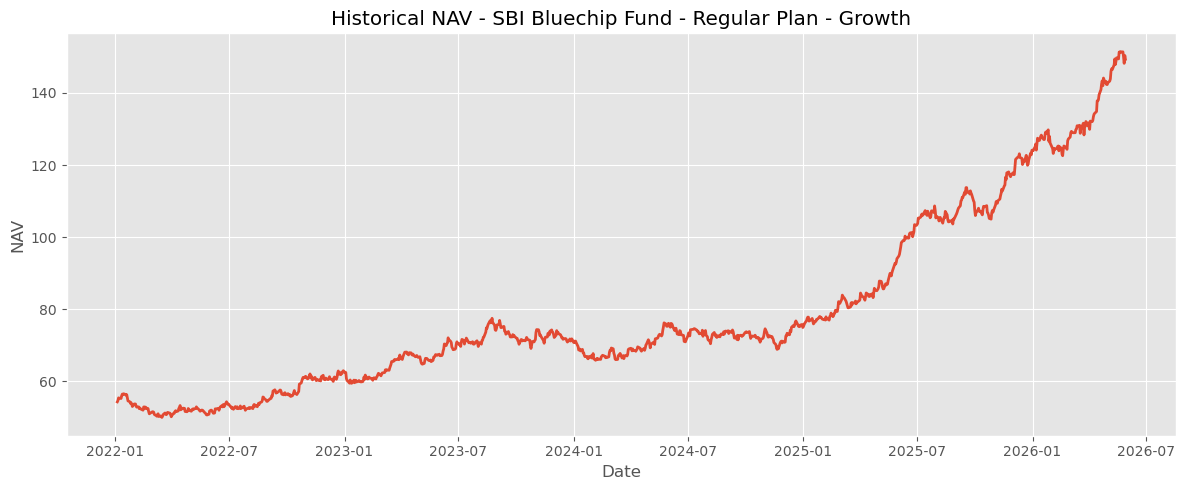

In [8]:
# ============================================================
# Historical NAV Analysis
# ============================================================

mean_return = fund_df["daily_return"].mean()

volatility = fund_df["daily_return"].std()

annual_return = mean_return * 252

annual_volatility = volatility * np.sqrt(252)

print("=" * 70)
print("HISTORICAL STATISTICS")
print("=" * 70)

print(f"Mean Daily Return : {mean_return:.6f}")
print(f"Daily Volatility  : {volatility:.6f}")
print(f"Annual Return     : {annual_return:.2%}")
print(f"Annual Volatility : {annual_volatility:.2%}")

# ------------------------------------------------------------
# Historical NAV Plot
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    fund_df["date"],
    fund_df["nav"],
    linewidth=2
)

plt.title(f"Historical NAV - {selected_scheme}")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.grid(True)

plt.tight_layout()

plt.show()

# 🎲 Monte Carlo Simulation Setup

Monte Carlo Simulation estimates thousands of possible future NAV paths based on historical return and volatility.

### Simulation Assumptions

- Investment Horizon: **5 Years**
- Trading Days per Year: **252**
- Number of Simulations: **1000**
- Model Used: **Geometric Brownian Motion (GBM)**

The simulation assumes that future daily returns follow a normal distribution based on historical statistics.

In [9]:
# ============================================================
# Monte Carlo Simulation Parameters
# ============================================================

SIMULATION_YEARS = 5
TRADING_DAYS = 252
TOTAL_DAYS = SIMULATION_YEARS * TRADING_DAYS
NUM_SIMULATIONS = 1000

initial_nav = fund_df["nav"].iloc[-1]

print("=" * 70)
print("SIMULATION PARAMETERS")
print("=" * 70)

print(f"Selected Fund       : {selected_scheme}")
print(f"Initial NAV         : {initial_nav:.2f}")
print(f"Simulation Years    : {SIMULATION_YEARS}")
print(f"Trading Days/Year   : {TRADING_DAYS}")
print(f"Total Days          : {TOTAL_DAYS}")
print(f"Simulations         : {NUM_SIMULATIONS}")

SIMULATION PARAMETERS
Selected Fund       : SBI Bluechip Fund - Regular Plan - Growth
Initial NAV         : 149.32
Simulation Years    : 5
Trading Days/Year   : 252
Total Days          : 1260
Simulations         : 1000


In [10]:
# ============================================================
# Estimate Drift & Volatility
# ============================================================

mu = fund_df["daily_return"].mean()
sigma = fund_df["daily_return"].std()

drift = mu - (0.5 * sigma ** 2)

print("=" * 70)
print("MODEL PARAMETERS")
print("=" * 70)

print(f"Mean Daily Return : {mu:.6f}")
print(f"Daily Volatility  : {sigma:.6f}")
print(f"Drift             : {drift:.6f}")

MODEL PARAMETERS
Mean Daily Return : 0.000917
Daily Volatility  : 0.008656
Drift             : 0.000879


In [11]:
# ============================================================
# Generate Random Returns
# ============================================================

np.random.seed(42)

random_returns = np.random.normal(
    loc=drift,
    scale=sigma,
    size=(TOTAL_DAYS, NUM_SIMULATIONS)
)

print("=" * 70)
print("RANDOM RETURN MATRIX")
print("=" * 70)

print(f"Matrix Shape : {random_returns.shape}")

display(pd.DataFrame(random_returns).head())

RANDOM RETURN MATRIX
Matrix Shape : (1260, 1000)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999
0,0.005179,-0.000318,0.006486,0.014063,-0.001148,-0.001147,0.014549,0.007522,-0.003185,0.005576,-0.003132,-0.

In [12]:
# ============================================================
# Monte Carlo Simulation
# ============================================================

simulation_matrix = np.zeros(
    (TOTAL_DAYS + 1, NUM_SIMULATIONS)
)

simulation_matrix[0] = initial_nav

for day in range(1, TOTAL_DAYS + 1):

    simulation_matrix[day] = (
        simulation_matrix[day - 1]
        * np.exp(random_returns[day - 1])
    )

print("=" * 70)
print("SIMULATION COMPLETED")
print("=" * 70)

print(f"Simulation Matrix Shape : {simulation_matrix.shape}")

SIMULATION COMPLETED
Simulation Matrix Shape : (1261, 1000)


In [13]:
# ============================================================
# Preview Simulated NAV Paths
# ============================================================

simulation_df = pd.DataFrame(simulation_matrix)

display(simulation_df.iloc[:10, :10])

print("\nFinal Simulated NAV Preview")

display(simulation_df.tail())

,0,1,2,3,4,5,6,7,8,9
0,149.321600,149.321600,149.321600,149.321600,149.321600,149.321600,149.321600,149.321600,149.321600,149.321600
1,150.096948,149.274194,150.293234,151.436363,149.150342,149.150363,151.510030,150.449103,148.846831,150.156526
2,152.059815,150.606139,150.503117,150.723156,150.186546,149.790912,152.822973,151.411668,150.337439,149.593923
3,151.306678,150.550174,149.605781,150.454134,147.874777,150.199749,152.959010,150.476779,151.330822,150.945622
4,148.959365,149.564540,149.202247,153.067344,148.719626,148.604005,153.739034,148.605360,152.890157,150.463540
5,147.980164,149.655686,149.356795,153.830068,147.099649,149.499620,150.313921,147.927320,152.379242,151.423778
6,147.568043,149.200595,147.182567,153.526089,148.165983,147.989757,151.817815,148.683922,151.547033,151.371427
7,146.280338,148.518494,146.115639,152.933967,148.021679,149.197218,151.529527,146.786099,153.184659,150.410742
8,147.407524,146.379227,147.151804,152.759133,149.061956,150.336140,153.788521,148.646594,155.117014,152.436177
9,147.495030,145.870653,147.061657,153.842391,150.852549,151.213290,154.059408,150.719154,154.833615,153.937899



Final Simulated NAV Preview


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999
1256,720.691186,361.500098,338.108559,525.516882,485.845301,416.822436,611.808993,399.263977,660.644892,691.0

# 📈 5-Year Monte Carlo NAV Forecast Visualization

The following visualization displays all simulated NAV paths over the next **5 years**.

The chart includes:

- 1,000 simulated future NAV paths
- Mean expected NAV trajectory
- 95% Confidence Interval

This visualization demonstrates both the expected growth trend and the uncertainty associated with future market movements.

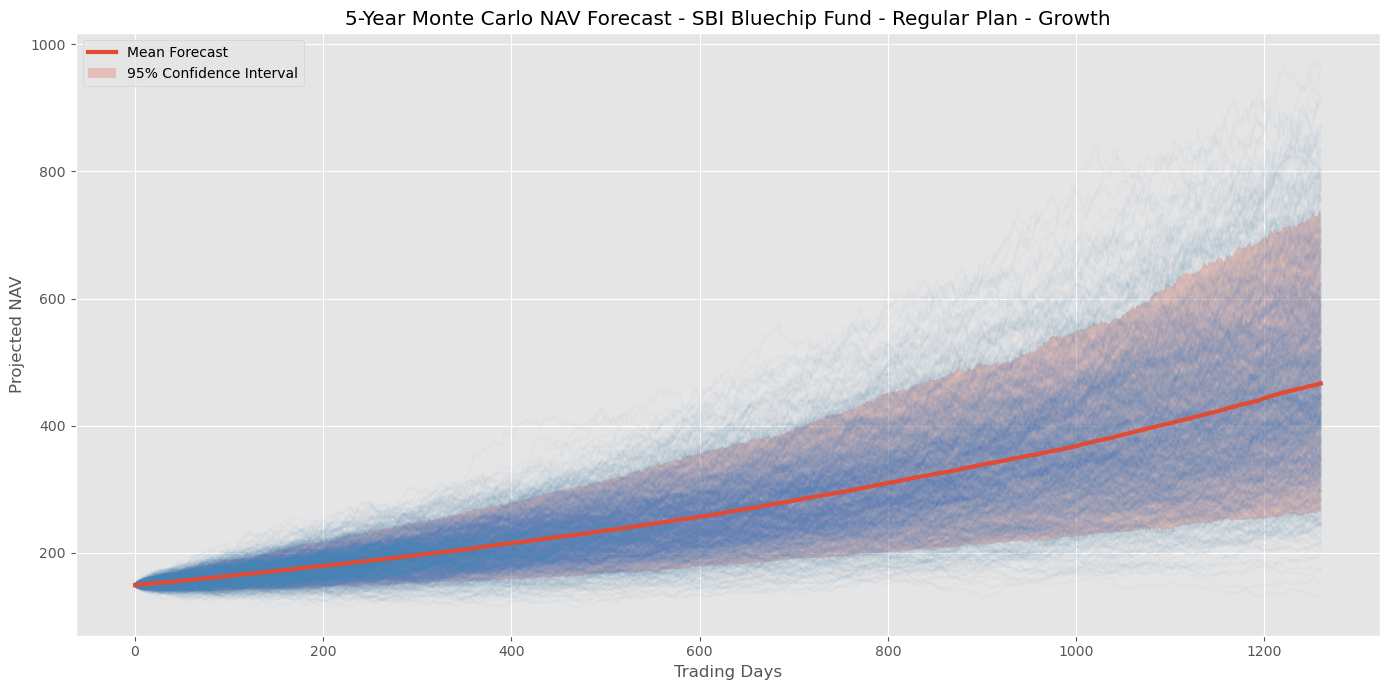

In [14]:
# ============================================================
# Monte Carlo Simulation Plot
# ============================================================

mean_path = simulation_df.mean(axis=1)

lower_ci = simulation_df.quantile(0.05, axis=1)

upper_ci = simulation_df.quantile(0.95, axis=1)

plt.figure(figsize=(14,7))

# Plot simulation paths
plt.plot(
    simulation_df,
    color="steelblue",
    alpha=0.03
)

# Mean Forecast
plt.plot(
    mean_path,
    linewidth=3,
    label="Mean Forecast"
)

# Confidence Interval
plt.fill_between(
    mean_path.index,
    lower_ci,
    upper_ci,
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title(f"5-Year Monte Carlo NAV Forecast - {selected_scheme}")

plt.xlabel("Trading Days")

plt.ylabel("Projected NAV")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "monte_carlo_simulation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📊 Distribution of Final NAV Values

The histogram below illustrates the distribution of simulated NAV values at the end of the **5-year investment horizon**.

Key statistics highlighted:

- Mean Ending NAV
- Median Ending NAV
- 5th Percentile (Worst Case)
- 95th Percentile (Best Case)

This provides a probabilistic view of potential investment outcomes.

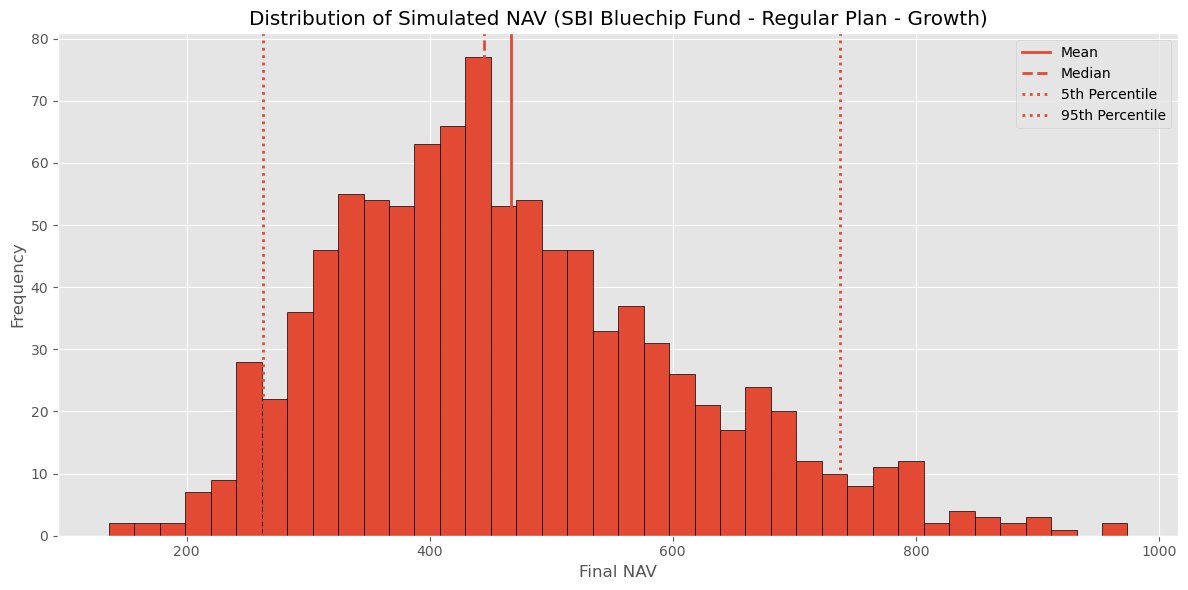

In [15]:
# ============================================================
# Distribution of Final NAV
# ============================================================

final_nav = simulation_df.iloc[-1]

mean_final = final_nav.mean()

median_final = final_nav.median()

lower_final = final_nav.quantile(0.05)

upper_final = final_nav.quantile(0.95)

plt.figure(figsize=(12,6))

plt.hist(
    final_nav,
    bins=40,
    edgecolor="black"
)

plt.axvline(mean_final, linewidth=2, label="Mean")

plt.axvline(median_final, linewidth=2, linestyle="--", label="Median")

plt.axvline(lower_final, linewidth=2, linestyle=":", label="5th Percentile")

plt.axvline(upper_final, linewidth=2, linestyle=":", label="95th Percentile")

plt.title(f"Distribution of Simulated NAV ({selected_scheme})")

plt.xlabel("Final NAV")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "monte_carlo_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# ============================================================
# Monte Carlo Summary Statistics
# ============================================================

expected_cagr = (
    (mean_final / initial_nav) ** (1 / SIMULATION_YEARS)
) - 1

probability_growth = (
    (final_nav > initial_nav).mean()
) * 100

probability_loss = (
    (final_nav < initial_nav).mean()
) * 100

summary_df = pd.DataFrame({

    "Metric":[

        "Starting NAV",

        "Mean Ending NAV",

        "Median Ending NAV",

        "Best Case (95%)",

        "Worst Case (5%)",

        "Expected CAGR",

        "Probability of Growth (%)",

        "Probability of Loss (%)",

        "Simulation Years",

        "Number of Simulations"

    ],

    "Value":[

        round(initial_nav,2),

        round(mean_final,2),

        round(median_final,2),

        round(upper_final,2),

        round(lower_final,2),

        f"{expected_cagr:.2%}",

        round(probability_growth,2),

        round(probability_loss,2),

        SIMULATION_YEARS,

        NUM_SIMULATIONS

    ]

})

display(summary_df)

summary_df.to_csv(

    REPORT_PATH / "monte_carlo_summary.csv",

    index=False

)

,Metric,Value
0,Starting NAV,149.32
1,Mean Ending NAV,466.53
2,Median Ending NAV,444.67
3,Best Case (95%),737.46
4,Worst Case (5%),263.14
5,Expected CAGR,25.59%
6,Probability of Growth (%),99.9
7,Probability of Loss (%),0.1
8,Simulation Years,5
9,Number of Simulations,1000


### Investment Insight

The Monte Carlo simulation projects
an expected NAV of ₹466.53 after five years.

95% of simulated outcomes fall between

₹263.14 and ₹737.46.

This indicates substantial long-term
growth potential while acknowledging
the uncertainty associated with market returns.

# 📌 Investment Interpretation

### Key Findings

- The Monte Carlo Simulation generated **1,000 possible future NAV paths** over a **5-year investment horizon**.
- The **mean forecast** represents the expected NAV trajectory based on historical return and volatility.
- The **95% confidence interval** captures the range within which most simulated outcomes are expected to fall.
- The distribution of final NAV values highlights the uncertainty associated with long-term investing while also illustrating the expected growth potential.

### Conclusion

Monte Carlo Simulation provides a probabilistic framework for evaluating future mutual fund performance. Rather than predicting a single outcome, it presents a range of possible scenarios, enabling investors to better understand risk, return, and long-term investment uncertainty.

The analysis indicates that, under historical market conditions, the selected mutual fund demonstrates positive long-term growth potential while acknowledging the inherent variability of financial markets.